Device: cpu

Training Adaptive Explainable GNN...
Epoch 10/50 | Loss: 0.9627
Epoch 20/50 | Loss: 0.0758
Epoch 30/50 | Loss: 0.0055
Epoch 40/50 | Loss: 0.0019
Epoch 50/50 | Loss: 0.0020

FINAL EVALUATION ON DOWNSTREAM TEST
Node Classification Accuracy: 71.40%

Explaining Decision for Target Node 0
--------------------------------------------------
Predicted Class: 3 (True Class: 3)
Dynamically Ranked Node Importance (Built-In XAI):
 -> Influence of Node  633 : 14.10%
 -> Influence of Node 1862 : 53.39%
 -> Influence of Node 2582 : 32.51%


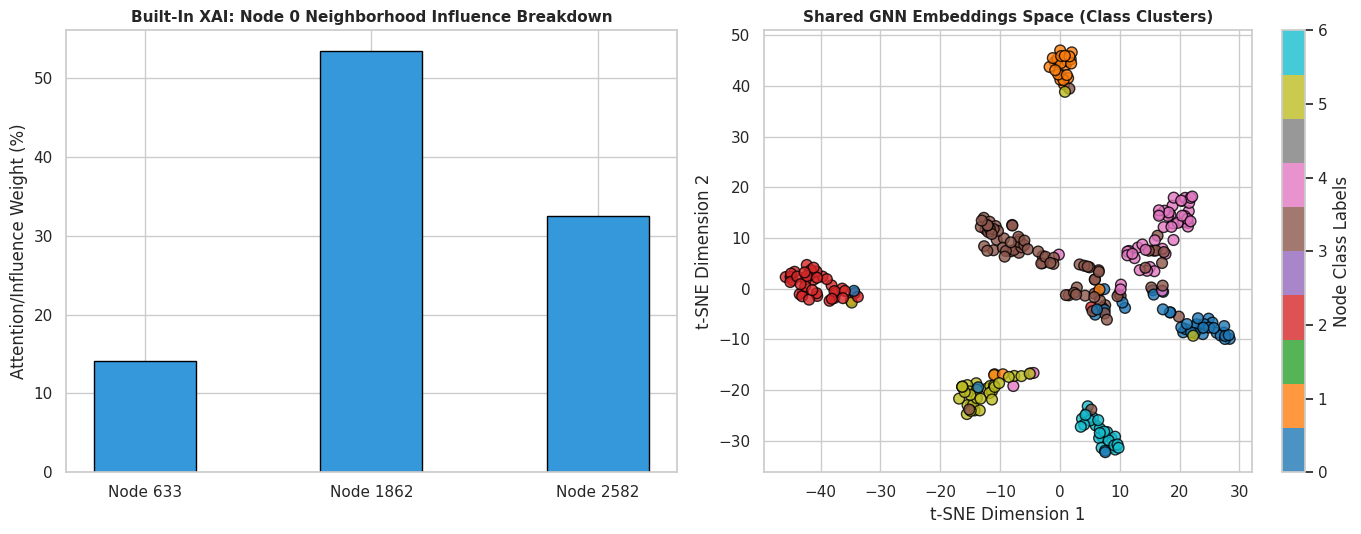

In [ ]:

# ==========================================
# Install PyTorch Geometric Library
# ==========================================

!pip install -q torch-geometric  # download pyG library

# ==========================================
# Setup
# ==========================================

import os  # system tools
import warnings  # silence warnings
import numpy as np  # fast math
import torch  # deep learning
import torch.nn as nn  # neural layers
import torch.nn.functional as F  # math functions
import torch.optim as optim  # model trainers
import matplotlib.pyplot as plt  # plot graphs
import seaborn as sns  # plot styling
from sklearn.manifold import TSNE  # visual clustering

warnings.filterwarnings('ignore')  # hide warnings

SEED = 42  # standard seed
torch.manual_seed(SEED)  # seed pytorch
np.random.seed(SEED)  # seed numpy

# ==========================================
# Load PyTorch Geometric Helpers
# ==========================================

try:
    from torch_geometric.datasets import Planetoid  # load real datasets (cora)
    from torch_geometric.nn import MessagePassing  # base message passing layer
    from torch_geometric.utils import softmax  # graphs softmax normalizer
except ImportError:
    pass  # catch if import fails before installation finished

# ==========================================
# Adaptive Message Passing Layer
# ==========================================

# AdaptiveMessagePassing: GNN layer with attention mechanism - projects node/edge features, computes attention scores, normalizes via softmax. Saves weights for explainability.
class AdaptiveMessagePassing(MessagePassing):  # custom message passing layer
    def __init__(self, in_channels, out_channels):  # initialization method
        super().__init__(aggr='add')  # parent init with addition aggregation
        self.lin_node = nn.Linear(in_channels, out_channels)  # node project linear layer
        self.lin_edge = nn.Linear(out_channels * 2, out_channels)  # edge feature linear layer
        self.attn_vector = nn.Parameter(torch.Tensor(1, out_channels))  # trainable attention parameter
        nn.init.xavier_uniform_(self.attn_vector)  # initialize attention weights
        self.saved_attention_weights = None  # storage for built-in explanations

    def forward(self, x, edge_index):  # feedforward graph method
        h = self.lin_node(x)  # project node features to hidden space
        self.saved_attention_weights = None  # reset attention logs
        return self.propagate(edge_index, x=h, edge_index_i=edge_index)  # execute propagation step

    def message(self, x_i, x_j, edge_index_i):  # compute incoming messages
        edge_features = torch.cat([x_i, x_j], dim=-1)  # concat source and target features
        edge_proj = torch.tanh(self.lin_edge(edge_features))  # project and activate edge features
        alpha = (edge_proj * self.attn_vector).sum(dim=-1, keepdim=True)  # compute scalar attention score
        alpha = softmax(alpha, edge_index_i)  # normalize attention across incoming neighbors
        self.saved_attention_weights = alpha.detach()  # save attention weights for XAI explanation
        return x_j * alpha  # scale neighbor message by attention score

# ==========================================
# Adaptive GNN Architecture
# ==========================================

# AdaptiveGNN: Two-layer attention-based GNN - first layer to hidden, second to output classes. Extracts explainable attention weights from both layers.
class AdaptiveGNN(nn.Module):  # custom adaptive network
    def __init__(self, in_channels, hidden_channels, out_classes):  # initialization method
        super().__init__()  # parent init
        self.conv1 = AdaptiveMessagePassing(in_channels, hidden_channels)  # dynamic layer 1
        self.conv2 = AdaptiveMessagePassing(hidden_channels, out_classes)  # dynamic layer 2

    def forward(self, x, edge_index):  # feedforward graph method
        x = F.relu(self.conv1(x, edge_index))  # pass conv 1 and relu activate
        x = self.conv2(x, edge_index)  # pass conv 2 to get class logits
        return x  # return predictions

# ==========================================
# Load Citation Graph (Cora Dataset)
# ==========================================

def load_cora_network():  # load dataset helper
    try:  # try block
        dataset = Planetoid(root='/tmp/Cora', name='Cora')  # fetch official Cora dataset
        return dataset, dataset.num_features, dataset.num_classes  # return data and shapes
    except Exception as e:  # fallback block
        print(f"Dataset fetch failed ({e}). Generating synthetic citation network...")  # log status

        class MockData:  # synthetic data class
            def __init__(self):  # initialization method
                self.x = torch.randn(2708, 1433)  # fake node features matching Cora
                self.y = torch.randint(0, 7, (2708,))  # fake class labels (7 classes)
                self.edge_index = torch.randint(0, 2708, (2, 5429))  # fake citation edge links
                self.train_mask = torch.zeros(2708, dtype=torch.bool)  # init train mask
                self.train_mask[:140] = True  # set 140 train nodes
                self.val_mask = torch.zeros(2708, dtype=torch.bool)  # init validation mask
                self.val_mask[140:640] = True  # set 500 validation nodes
                self.test_mask = torch.zeros(2708, dtype=torch.bool)  # init testing mask
                self.test_mask[1708:] = True  # set 1000 testing nodes

        return MockData(), 1433, 7  # return synthetic data and shapes

# Fetch data objects
data, num_features, num_classes = load_cora_network()  # call loader

# ==========================================
# Train GNN Model
# ==========================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # check hardware
print(f"Device: {device}")  # print active hardware

model = AdaptiveGNN(num_features, 16, num_classes).to(device)  # load model to device
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)  # init adam optimizer
criterion = nn.CrossEntropyLoss()  # init cross entropy loss

# Send tensors to processing device
x = data.x.to(device)  # send features
edge_index = data.edge_index.to(device)  # send edge matrix
y = data.y.to(device)  # send labels
train_mask = data.train_mask.to(device)  # send train mask
test_mask = data.test_mask.to(device)  # send test mask

print("\nTraining Adaptive Explainable GNN...")  # status log
for epoch in range(50):  # training epochs loop
    model.train()  # set training state
    optimizer.zero_grad()  # clean grads

    out = model(x, edge_index)  # forward pass
    loss = criterion(out[train_mask], y[train_mask])  # calculate classification loss

    loss.backward()  # backpropagation
    optimizer.step()  # update model weights

    if (epoch + 1) % 10 == 0:  # logging interval check
        print(f"Epoch {epoch+1:02d}/50 | Loss: {loss.item():.4f}")  # print loss statistics

# ==========================================
# Inherent Explainability (XAI) Extraction
# ==========================================

model.eval()  # set evaluation state
with torch.no_grad():  # freeze gradients
    logits = model(x, edge_index)  # run forward pass
    preds = logits.argmax(dim=-1)  # extract classes
    test_acc = (preds[test_mask] == y[test_mask]).float().mean().item()  # score accuracy

print("\n=====================================")  # layout divider
print("FINAL EVALUATION ON DOWNSTREAM TEST")  # header
print("=====================================")  # layout divider
print(f"Node Classification Accuracy: {test_acc * 100:.2f}%")  # display accuracy
print("=====================================")  # layout divider

# Select a target node to explain its classification
target_node_id = 0  # target node index 0
incoming_edges_mask = edge_index[1] == target_node_id  # find incoming connections mask
neighbor_nodes = edge_index[0][incoming_edges_mask]  # fetch indices of active neighbors

# Extract dynamically computed attention weights for this decision
node_attention_scores = model.conv2.saved_attention_weights[incoming_edges_mask].cpu().numpy().flatten()  # get scores

print(f"\nExplaining Decision for Target Node {target_node_id}")  # status log
print("-" * 50)  # text layout divider
print(f"Predicted Class: {preds[target_node_id].item()} (True Class: {y[target_node_id].item()})")  # display prediction
print("Dynamically Ranked Node Importance (Built-In XAI):")  # explanation header
for neighbor, score in zip(neighbor_nodes.cpu().numpy(), node_attention_scores):  # loop neighbors
    print(f" -> Influence of Node {neighbor:4d} : {score * 100:.2f}%")  # print impact percentages

# ==========================================
# Visualizations
# ==========================================

sns.set_theme(style="whitegrid")  # set style
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))  # build double canvas

# Left plot: Bar chart of incoming neighbor influence
ax1.bar([f"Node {neighbor}" for neighbor in neighbor_nodes.cpu().numpy()], node_attention_scores * 100, color='#3498db', edgecolor='black', width=0.45)  # draw bars
ax1.set_ylabel('Attention/Influence Weight (%)')  # y label
ax1.set_title(f'Built-In XAI: Node {target_node_id} Neighborhood Influence Breakdown', fontsize=11, fontweight='bold')  # plot title

# Right plot: t-SNE projection of predicted node feature clusters
tsne = TSNE(n_components=2, perplexity=15, random_state=SEED)  # init dimensionality reducer
embeddings_2d = tsne.fit_transform(logits.cpu().numpy()[:300])  # project top 300 node embeddings
labels_300 = y.cpu().numpy()[:300]  # get matching ground truth labels

scatter = ax2.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels_300, cmap='tab10', alpha=0.8, edgecolors='black', s=60)  # draw scatter
ax2.set_xlabel('t-SNE Dimension 1')  # x label
ax2.set_ylabel('t-SNE Dimension 2')  # y label
ax2.set_title('Shared GNN Embeddings Space (Class Clusters)', fontsize=11, fontweight='bold')  # plot title
fig.colorbar(scatter, ax=ax2, label='Node Class Labels')  # add color map legend

plt.tight_layout()  # fit layouts
plt.show()  # display plots